# Fraud Detection - Ensemble Model Training

## Objectives
1. Load and explore transaction data to understand fraud patterns
2. Engineer features that capture suspicious behavior
3. **Use sklearn Pipeline** for reproducible preprocessing
4. Train **two models**: XGBoost and Random Forest
5. Compare model performance using multiple metrics
6. Save **complete pipelines** for deployment

## Architecture Overview
```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                    ENSEMBLE FRAUD DETECTION PIPELINE                            │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│   Part 1 (This Notebook)     Part 2 (FastAPI)       Part 3 (Streamlit)         │
│   ──────────────────────     ────────────────       ─────────────────          │
│   📥 Load data               🔌 /predict API        📝 User input form          │
│   📊 Exploratory analysis    📦 Load models         📡 Call FastAPI             │
│   🛠️ Feature engineering     🔮 Return predictions  ✅ Show results             │
│   🤖 Train XGBoost                                                              │
│   🤖 Train Random Forest                                                        │
│   💾 Save models                                                                │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

**Data Source**: [Hopsworks Fraud Tutorial Data](https://repo.hops.works/master/hopsworks-tutorials/data/card_fraud_data/)

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# we will save our models here to deploy later using FASTAAPI & Streamlit

# example path "/content/drive/MyDrive/2026_work/model-train_deployement"

In [1]:
# Install required packages (run once if needed)
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib contextily --quiet

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx # Added contextily import

# Math utilities
from math import radians  # For converting degrees to radians (used in Haversine formula)

# File I/O
import json
import joblib  # For saving/loading sklearn models
import os

# Machine Learning
import xgboost as xgb  # Gradient boosting library
from sklearn.ensemble import RandomForestClassifier  # Bagging ensemble method
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder  # For categorical encoding in pipelines
from sklearn.compose import ColumnTransformer  # Apply different transforms to different columns
from sklearn.pipeline import Pipeline  # Chain preprocessing + model together
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Step 1: Load Data

We load data from three CSV files:
- **credit_cards.csv**: Card information (expiration date, provider)
- **profiles.csv**: Customer demographics (birthdate, location)
- **transactions.csv**: Transaction events with fraud labels

In [ ]:
print("="*60)
print("STEP 1: LOAD DATA")
print("="*60)

# Data URL from Hopsworks tutorials
DATA_URL = "../data"

print(f"\nLoading data from: {DATA_URL}")

# Load credit card information
# Contains: cc_num (card number), provider, expires (expiration date)
credit_cards_df = pd.read_csv(DATA_URL + "credit_cards.csv")
print(f"   credit_cards.csv: {len(credit_cards_df):,} rows")

# Load customer profiles
# parse_dates automatically converts 'birthdate' string to datetime object
profiles_df = pd.read_csv(DATA_URL + "profiles.csv", parse_dates=["birthdate"])
print(f"   profiles.csv: {len(profiles_df):,} rows")

# Load transaction data
# This is our main dataset with fraud labels (0=legit, 1=fraud)
trans_df = pd.read_csv(DATA_URL + "transactions.csv", parse_dates=["datetime"])
print(f"   transactions.csv: {len(trans_df):,} rows")

# Calculate fraud rate - important for understanding class imbalance
fraud_rate = trans_df['fraud_label'].mean() * 100
print(f"\nFraud Statistics:")
print(f"   Total transactions: {len(trans_df):,}")
print(f"   Fraudulent: {trans_df['fraud_label'].sum():,} ({fraud_rate:.2f}%)")
print(f"   Legitimate: {(~trans_df['fraud_label'].astype(bool)).sum():,} ({100-fraud_rate:.2f}%)")

STEP 1: LOAD DATA

Loading data from: https://repo.hops.works/master/hopsworks-tutorials/data/card_fraud_data/
   credit_cards.csv: 2,000 rows
   profiles.csv: 2,000 rows
   transactions.csv: 106,020 rows

Fraud Statistics:
   Total transactions: 106,020
   Fraudulent: 155 (0.15%)
   Legitimate: 105,865 (99.85%)


!Highly imbalanced data

In [4]:
# Preview the data
print("\n Sample Cc records:")
credit_cards_df.head(3)


 Sample Cc records:


,cc_num,provider,expires
0,4796807885357879,visa,05/23
1,4529266636192966,visa,03/22
2,4922690008243953,visa,02/27


In [5]:
# Preview the data
print("\n Sample profiles:")
profiles_df.head(3)


 Sample profiles:


,name,sex,mail,birthdate,City,Country,cc_num
0,Catherine Zimmerman,F,valenciajason@hotmail.com,1988-09-20,Bryn Mawr-Skyway,US,4796807885357879
1,Michael Williams,M,brettkennedy@yahoo.com,1977-03-01,Gates-North Gates,US,4529266636192966
2,Jessica Krueger,F,marthacruz@hotmail.com,1947-09-10,Greenfield,US,4922690008243953


In [6]:
# Preview the transaction data
# Key columns: tid (transaction ID), cc_num (card), amount, datetime, fraud_label
print("\nSample transactions:")
trans_df.head()


Sample transactions:


,tid,datetime,cc_num,category,amount,latitude,longitude,city,country,fraud_label
0,11df919988c134d97bbff2678eb68e22,2022-01-01 00:00:24,4473593503484549,Health/Beauty,62.95,42.30865,-83.48216,Canton,US,0
1,dd0b2d6d4266ccd3bf05bc2ea91cf180,2022-01-01 00:00:56,4272465718946864,Grocery,85.45,33.52253,-117.70755,Laguna Niguel,US,0
2,e627f5d9a9739833bd52d2da51761fc3,2022-01-01 00:02:32,4104216579248948,Domestic Transport,21.63,37.60876,-77.37331,Mechanicsville,US,0
3,6fb3e6beafbb92b8e15827037f603c52,2022-01-01 00:03:24,4814447237003448,Health/Beauty,54.71,43.54072,-116.56346,Nampa,US,0
4,be0b8acc57bfe126a5a392fd99e6ddd1,2022-01-01 00:03:55,4515188652242507,Grocery,59.22,40.24537,-75.64963,Pottstown,US,0


---
## Step 2: Exploratory Data Analysis (EDA)

Before feature engineering, let's understand our data:
- What does the fraud distribution look like?
- Are there patterns in transaction amounts, times, or categories?
- What columns might be useful for detecting fraud?

In [7]:
print("="*60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Check data types and missing values
print("\n--- Data Info ---")
print(f"Columns: {list(trans_df.columns)}")
print(f"\nMissing values per column:")
print(trans_df.isnull().sum())

STEP 2: EXPLORATORY DATA ANALYSIS

--- Data Info ---
Columns: ['tid', 'datetime', 'cc_num', 'category', 'amount', 'latitude', 'longitude', 'city', 'country', 'fraud_label']

Missing values per column:
tid            0
datetime       0
cc_num         0
category       0
amount         0
latitude       0
longitude      0
city           0
country        0
fraud_label    0
dtype: int64


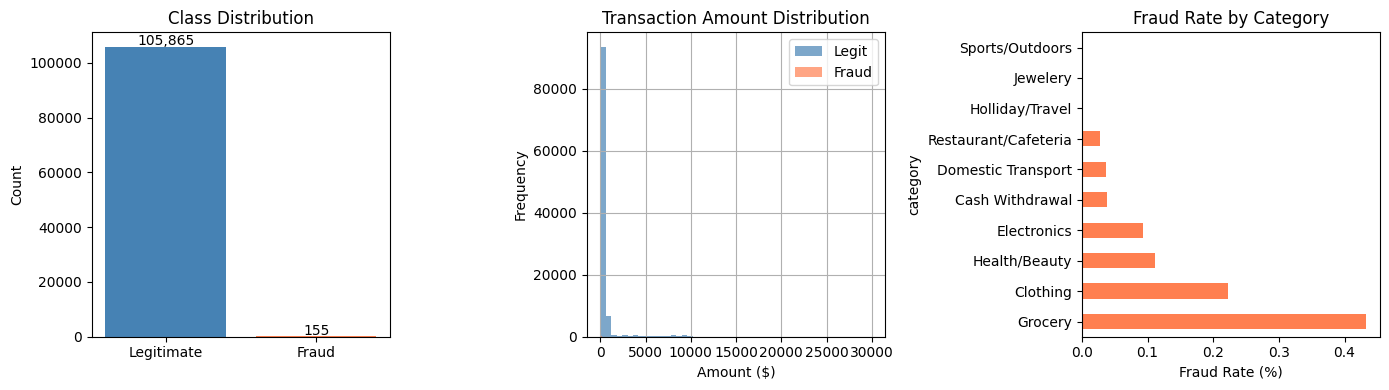


Key Observations:
   1. Severe class imbalance: Only 0.15% are fraud
   2. Fraud spans all amount ranges (no simple threshold)
   3. Some categories have higher fraud rates than others


In [8]:
# Visualize class imbalance
# This is CRITICAL - highly imbalanced classes require special handling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Fraud distribution (bar chart)
ax1 = axes[0]
fraud_counts = trans_df['fraud_label'].value_counts()
bars = ax1.bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'coral'])
ax1.set_title('Class Distribution')
ax1.set_ylabel('Count')
# Add count labels on bars
for bar, count in zip(bars, fraud_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}', ha='center', fontsize=10)

# Plot 2: Transaction amount distribution by fraud label
ax2 = axes[1]
# Using log scale because amounts can vary widely
trans_df[trans_df['fraud_label']==0]['amount'].hist(bins=50, alpha=0.7, label='Legit', ax=ax2, color='steelblue')
trans_df[trans_df['fraud_label']==1]['amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=ax2, color='coral')
ax2.set_title('Transaction Amount Distribution')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Frequency')
ax2.legend()

# Plot 3: Fraud rate by category
ax3 = axes[2]
category_fraud = trans_df.groupby('category')['fraud_label'].mean().sort_values(ascending=False) * 100
category_fraud.plot(kind='barh', ax=ax3, color='coral')
ax3.set_title('Fraud Rate by Category')
ax3.set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print(f"   1. Severe class imbalance: Only {fraud_rate:.2f}% are fraud")
print(f"   2. Fraud spans all amount ranges (no simple threshold)")
print(f"   3. Some categories have higher fraud rates than others")

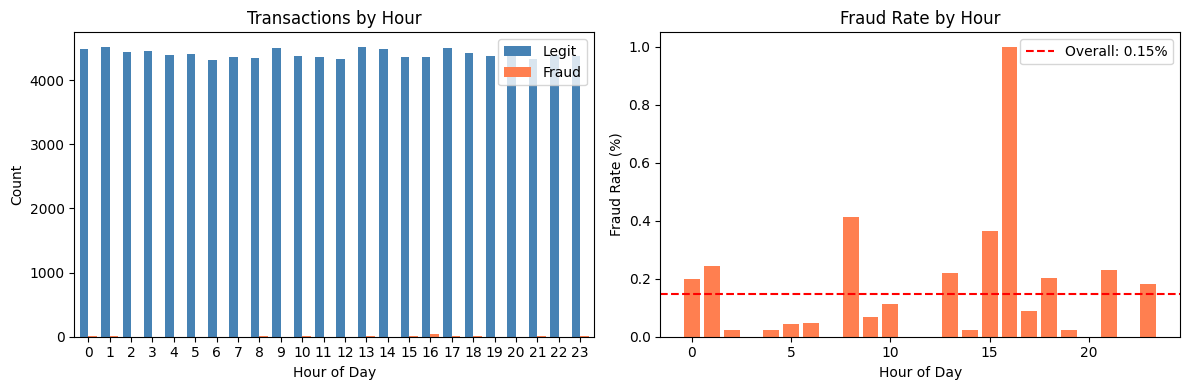

In [9]:
# Analyze temporal patterns
# Fraudsters might operate at specific times (e.g., late night)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Extract hour from datetime
trans_df['hour'] = trans_df['datetime'].dt.hour

# Plot 1: Transaction volume by hour
ax1 = axes[0]
hourly_counts = trans_df.groupby(['hour', 'fraud_label']).size().unstack(fill_value=0)
hourly_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'coral'], width=0.8)
ax1.set_title('Transactions by Hour')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Count')
ax1.legend(['Legit', 'Fraud'])
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Fraud RATE by hour (more meaningful than count)
ax2 = axes[1]
hourly_fraud_rate = trans_df.groupby('hour')['fraud_label'].mean() * 100
ax2.bar(hourly_fraud_rate.index, hourly_fraud_rate.values, color='coral')
ax2.axhline(y=fraud_rate, color='red', linestyle='--', label=f'Overall: {fraud_rate:.2f}%')
ax2.set_title('Fraud Rate by Hour')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Fraud Rate (%)')
ax2.legend()

# Clean up temporary column
trans_df.drop('hour', axis=1, inplace=True)

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics for numerical columns
print("\n--- Numerical Summary ---")
trans_df[['amount', 'latitude', 'longitude']].describe().round(2)


--- Numerical Summary ---


,amount,latitude,longitude
count,106020.00,106020.00,106020.00
mean,421.12,37.91,-91.93
std,1452.55,5.35,17.61
min,0.01,-23.86,-156.50
25%,26.74,33.93,-104.23
50%,60.48,39.33,-87.66
75%,94.02,41.58,-77.39
max,29968.32,55.85,144.23


VISUALIZING LOCATION DATA
Latitude and longitude are in degrees for plotting, no conversion needed.


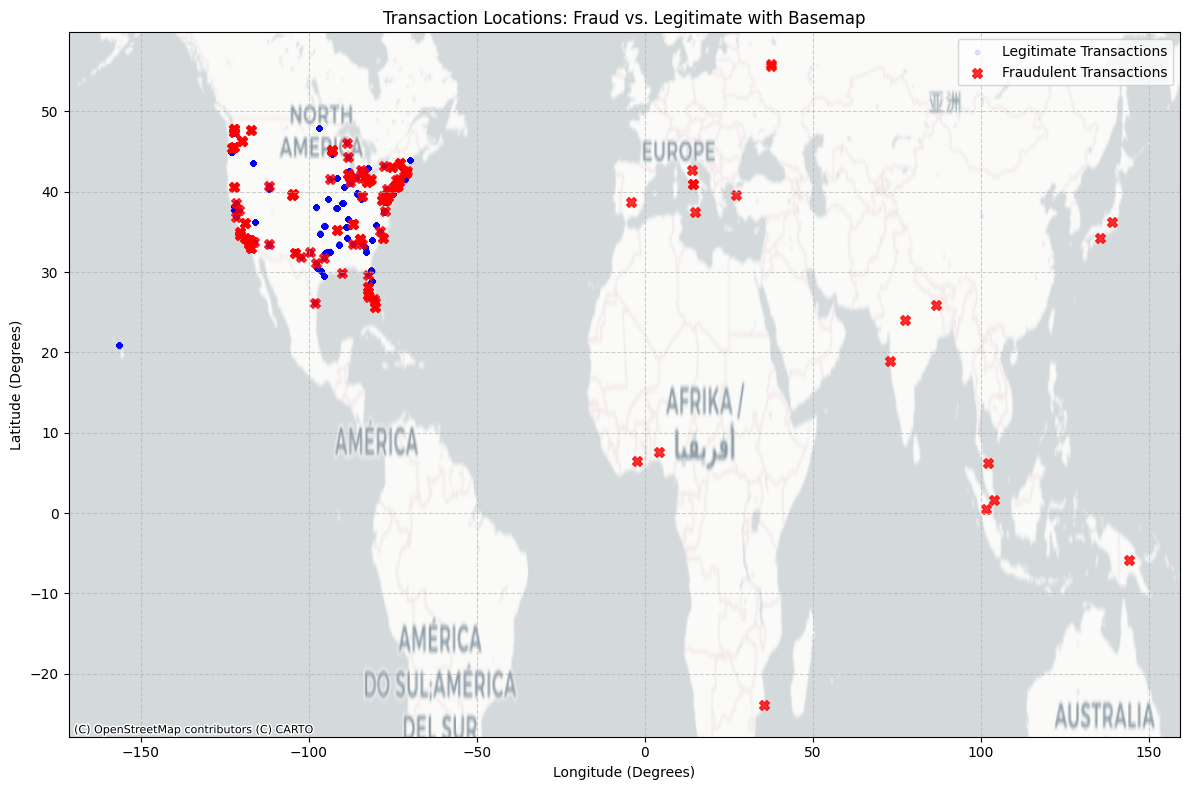


Observation: The map shows the distribution of transactions with a geographical context provided by the basemap. Fraudulent transactions (red 'X' marks) often occur within the same general regions as legitimate ones, but can sometimes appear as outliers, indicating potential suspicious activity based on location.


In [11]:
print("="*60)
print("VISUALIZING LOCATION DATA")
print("="*60)

# Make a copy to avoid modifying the original dataframe unnecessarily for plotting
plot_df = trans_df.copy()

# At this point, trans_df's longitude and latitude are in degrees from initial loading.
# No conversion is needed for plotting with contextily's default crs='EPSG:4326'.
print("Latitude and longitude are in degrees for plotting, no conversion needed.")


# Separate fraudulent and legitimate transactions
fraud_locs = plot_df[plot_df['fraud_label'] == 1]
legit_locs = plot_df[plot_df['fraud_label'] == 0]

plt.figure(figsize=(12, 8))
ax = plt.gca() # Get the current axes

# Plot legitimate transactions (lighter color, semi-transparent)
ax.scatter(legit_locs['longitude'], legit_locs['latitude'],
           color='blue', alpha=0.1, s=10, label='Legitimate Transactions')

# Plot fraudulent transactions (distinct color, more prominent)
ax.scatter(fraud_locs['longitude'], fraud_locs['latitude'],
           color='red', alpha=0.8, s=50, marker='X', label='Fraudulent Transactions')

# Add the basemap using contextily
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)

ax.set_title('Transaction Locations: Fraud vs. Legitimate with Basemap')
ax.set_xlabel('Longitude (Degrees)')
ax.set_ylabel('Latitude (Degrees)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nObservation: The map shows the distribution of transactions with a geographical context provided by the basemap. Fraudulent transactions (red 'X' marks) often occur within the same general regions as legitimate ones, but can sometimes appear as outliers, indicating potential suspicious activity based on location.")

---
## Step 3: Feature Engineering

We create features that help detect fraud patterns:

**Cross-Source Features** (combine data from multiple tables):
- age_at_transaction: Customer age when transaction occurred
- days_until_card_expires: Days until card expiration

**Behavioral Features** (window aggregations over time):
- loc_delta: Distance between consecutive transactions (Haversine)
- trans_volume_mavg: 4h moving average of transaction amounts
- trans_volume_mstd: 4h moving std dev (high variance = suspicious)
- trans_freq: Transaction frequency in 4h window
- loc_delta_mavg: 4h moving average of location changes

In [13]:
print("="*60)
print("STEP 3: FEATURE ENGINEERING")
print("="*60)

# =========================================================================
# CROSS-SOURCE FEATURES
# These combine data from transactions with customer profiles and card info
# =========================================================================
print("\n--- Creating Cross-Source Features ---")

# Feature: age_at_transaction
# WHY: Elderly customers may be more vulnerable to fraud
# HOW: Merge with profiles to get birthdate, then calculate age at transaction time
age_df = trans_df.merge(profiles_df, on="cc_num", how="left")
trans_df["age_at_transaction"] = (age_df["datetime"] - age_df["birthdate"]) / np.timedelta64(365, "D")
print(f"   age_at_transaction: Age of cardholder at transaction time")

# Feature: days_until_card_expires
# WHY: Fraudsters may target cards about to expire (less monitoring)
# HOW: Merge with card info, calculate days between transaction and expiry
card_expiry_df = trans_df.merge(credit_cards_df, on="cc_num", how="left")
card_expiry_df["expires"] = pd.to_datetime(card_expiry_df["expires"], format="%m/%y")
trans_df["days_until_card_expires"] = (card_expiry_df["expires"] - card_expiry_df["datetime"]) / np.timedelta64(1, "D")
print(f"   days_until_card_expires: Days until card expiration")

STEP 3: FEATURE ENGINEERING

--- Creating Cross-Source Features ---
   age_at_transaction: Age of cardholder at transaction time
   days_until_card_expires: Days until card expiration


### Haversine Formula Visualization

![Haversine Formula](https://images.prismic.io/sketchplanations/e1e45776-aa40-4806-820e-b5c5b8050f4b_SP+687+-+The+haversine+formula.png?auto=compress,format)

In [15]:
# =========================================================================
# BEHAVIORAL FEATURES - Location Delta
# =========================================================================
print("\n--- Creating Behavioral Features ---")

# Sort transactions chronologically (required for sequential features)
trans_df.sort_values("datetime", inplace=True)

# Convert lat/long from degrees to radians (required for Haversine formula)
# The radians() function converts degrees to radians: radians = degrees * (pi/180)
trans_df[["longitude", "latitude"]] = trans_df[["longitude", "latitude"]].applymap(radians)

def haversine(long, lat):
    """
    Calculate Haversine distance between consecutive coordinates.

    The Haversine formula calculates the great-circle distance between two
    points on a sphere (Earth) given their latitudes and longitudes.

    WHY USE THIS: Fraudsters often make transactions in different locations
    in short time periods. Large location jumps are suspicious!

    Formula: a = sin^2(delta_lat/2) + cos(lat1) * cos(lat2) * sin^2(delta_long/2)
             c = 2 * arcsin(sqrt(a))
             distance = R * c  (R = Earth's radius)

    Args:
        long: Series of longitudes in radians
        lat: Series of latitudes in radians

    Returns:
        Series of distances between consecutive points (in radians, proportional to km)
    """
    # Shift to get previous transaction's location
    long_shifted = long.shift()
    lat_shifted = lat.shift()

    # Calculate differences
    long_diff = long_shifted - long
    lat_diff = lat_shifted - lat

    # Haversine formula components
    a = np.sin(lat_diff/2.0)**2
    b = np.cos(lat) * np.cos(lat_shifted) * np.sin(long_diff/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a + b))

    return c

# Feature: loc_delta
# WHY: Large distance between consecutive transactions (for same card) is suspicious
# HOW: Group by card number, apply Haversine to calculate distance between transactions
trans_df["loc_delta"] = trans_df.groupby("cc_num")\
    .apply(lambda x: haversine(x["longitude"], x["latitude"]))\
    .reset_index(level=0, drop=True)\
    .fillna(0)  # First transaction for each card has no previous location

print(f"   loc_delta: Distance from previous transaction (Haversine formula)")


--- Creating Behavioral Features ---
   loc_delta: Distance from previous transaction (Haversine formula)


In [21]:
# =========================================================================
# BEHAVIORAL FEATURES - Window Aggregations
# =========================================================================
# These capture patterns over a rolling time window (4 hours)
# WHY 4 HOURS: Fraudsters often make multiple transactions in short bursts
# =========================================================================

WINDOW_LEN = "4h"  # Rolling window size (4 hours)
print(f"\n--- Computing {WINDOW_LEN} Window Aggregations ---")

# Create rolling window groupby object
# This groups by credit card AND rolls over a 4-hour time window
cc_group = trans_df[["cc_num", "amount", "datetime"]].groupby("cc_num").rolling(
    WINDOW_LEN,
    on="datetime",
)

# ----- Feature: trans_volume_mavg -----
# WHY: Unusually high average transaction amounts in a short period = suspicious
df_4h_mavg = pd.DataFrame(cc_group.mean())
df_4h_mavg.columns = ["trans_volume_mavg", "datetime"]
df_4h_mavg = df_4h_mavg.reset_index(level=["cc_num"])
df_4h_mavg = df_4h_mavg.drop(columns=["cc_num", "datetime"])
df_4h_mavg = df_4h_mavg.sort_index()
print(f"   trans_volume_mavg: 4h moving average of transaction amount")

# ----- Feature: trans_volume_mstd -----
# WHY: High variance in amounts suggests testing with small amounts then big fraud
df_4h_std = pd.DataFrame(cc_group.std())
df_4h_std.columns = ["trans_volume_mstd", "datetime"]
df_4h_std = df_4h_std.reset_index(level=["cc_num"])
df_4h_std = df_4h_std.drop(columns=["cc_num", "datetime"])
df_4h_std = df_4h_std.fillna(0)  # Single transaction has no std dev
df_4h_std = df_4h_std.sort_index()
print(f"   trans_volume_mstd: 4h moving std dev of transaction amount")

# Merge the two aggregations
window_aggs_df = df_4h_std.merge(df_4h_mavg, left_index=True, right_index=True)

# ----- Feature: trans_freq -----
# WHY: Burst of transactions in short time = card testing or rapid fraud
df_4h_count = pd.DataFrame(cc_group.count())
df_4h_count.columns = ["trans_freq", "datetime"]
df_4h_count = df_4h_count.reset_index(level=["cc_num"])
df_4h_count = df_4h_count.drop(columns=["cc_num", "datetime"])
df_4h_count = df_4h_count.sort_index()
window_aggs_df = window_aggs_df.merge(df_4h_count, left_index=True, right_index=True)
print(f"   trans_freq: Number of transactions in 4h window")

# ----- Feature: loc_delta_mavg -----
# WHY: Consistently large location jumps over time = traveling fraud pattern
cc_group_loc = trans_df[["cc_num", "loc_delta", "datetime"]].groupby("cc_num").rolling(
    WINDOW_LEN,
    on="datetime",
)
df_4h_loc_mavg = pd.DataFrame(cc_group_loc.mean())
df_4h_loc_mavg.columns = ["loc_delta_mavg", "datetime"]
df_4h_loc_mavg = df_4h_loc_mavg.reset_index(level=["cc_num"])
df_4h_loc_mavg = df_4h_loc_mavg.drop(columns=["cc_num", "datetime"])
df_4h_loc_mavg = df_4h_loc_mavg.sort_index()
window_aggs_df = window_aggs_df.merge(df_4h_loc_mavg, left_index=True, right_index=True)
print(f"   loc_delta_mavg: 4h moving average of location changes")

# Merge all window aggregations back to main dataframe
trans_df = trans_df.merge(window_aggs_df, left_index=True, right_index=True)

print(f"\nFeature engineering complete!")
print(f"   Total columns: {len(trans_df.columns)}")
print(f"   Total rows: {len(trans_df):,}")


--- Computing 4h Window Aggregations ---
   trans_volume_mavg: 4h moving average of transaction amount
   trans_volume_mstd: 4h moving std dev of transaction amount
   trans_freq: Number of transactions in 4h window
   loc_delta_mavg: 4h moving average of location changes

Feature engineering complete!
   Total columns: 21
   Total rows: 106,020


In [ ]:
# Preview engineered features
feature_cols = ['age_at_transaction', 'days_until_card_expires', 'loc_delta',
                'trans_volume_mavg', 'trans_volume_mstd', 'trans_freq', 'loc_delta_mavg']
print("\n--- Engineered Features Preview ---")
trans_df[feature_cols].describe().round(2)

---
## Step 4: Prepare Training Data (with Pipeline)


In [ ]:
print("="*60)
print("STEP 4: PREPARE TRAINING DATA WITH PIPELINE")
print("="*60)

# =============================================================================
# DEFINE FEATURE COLUMNS
# Separating categorical vs numeric is important for ColumnTransformer
# =============================================================================
CATEGORICAL_COLS = ['category']  # Will be ordinally encoded
NUMERIC_COLS = [
    'amount',                # Transaction amount
    'age_at_transaction',    # Customer age at transaction
    'days_until_card_expires', # Days until card expiry
    'loc_delta',             # Distance from last transaction
    'trans_volume_mavg',     # 4h avg transaction amount
    'trans_volume_mstd',     # 4h std dev of amount
    'trans_freq',            # Transactions in 4h window
    'loc_delta_mavg'         # 4h avg location change
]
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
LABEL_COL = 'fraud_label'

print(f"\nFeature columns ({len(FEATURE_COLS)} total):")
print(f"   Categorical: {CATEGORICAL_COLS}")
print(f"   Numeric: {NUMERIC_COLS}")

# Drop rows with missing values
df = trans_df.dropna(subset=FEATURE_COLS + [LABEL_COL]).copy()
print(f"\n   Samples after dropping NaN: {len(df):,}")

In [ ]:
# =============================================================================
# CREATE PREPROCESSING PIPELINE (ColumnTransformer)
# =============================================================================
# ColumnTransformer applies different transformations to different column types:
# - Categorical columns: OrdinalEncoder (converts strings to integers)
# - Numeric columns: 'passthrough' (no transformation needed)
#
# WHY THIS MATTERS:
# - Prevents data leakage: encoder is fit ONLY on training data
# - Ensures consistency: same encoding applied during inference
# - Clean deployment: single pipeline object to save/load

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_COLS),  # Encode 'category' column
        ('num', 'passthrough', NUMERIC_COLS)  # Keep numeric columns as-is
    ],
    remainder='drop'  # Drop any columns not specified
)

print("Preprocessor created:")
print("   ColumnTransformer with:")
print("   - OrdinalEncoder for categorical columns")
print("   - Passthrough for numeric columns")
print("\n   Note: Preprocessor will be fit inside the Pipeline (after train/test split)")

In [ ]:
# =============================================================================
# TRAIN-TEST SPLIT (BEFORE any transformation - this prevents data leakage!)
# =============================================================================
# IMPORTANT: We split BEFORE fitting the preprocessor
# This ensures the encoder only sees training data categories

# Prepare X (raw features - NOT encoded yet) and y (target)
X = df[FEATURE_COLS]  # Raw features including 'category' as string
y = df[LABEL_COL]

# Train-test split with stratification (maintains fraud rate in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split complete (BEFORE preprocessing):")
print(f"   Training: {len(X_train):,} samples ({y_train.mean()*100:.2f}% fraud)")
print(f"   Test:     {len(X_test):,} samples ({y_test.mean()*100:.2f}% fraud)")
print(f"\n   Note: X contains raw features - preprocessing happens inside Pipeline")

---
## Step 5: Train Ensemble Models with Pipelines

We create **complete pipelines** that include:
1. **Preprocessor** (ColumnTransformer) - handles categorical encoding
2. **Model** (XGBoost or Random Forest)

**Why Pipeline?**
- Single `.fit()` call does both preprocessing and training
- Single `.predict()` call works on raw data
- Easy to save/load for deployment
- Prevents data leakage automatically

In [ ]:
print("="*60)
print("STEP 5: TRAIN ENSEMBLE MODELS")
print("="*60)

# Calculate class weight for imbalanced data
# This tells the model: "fraud samples are X times more important"
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance: {scale_pos_weight:.1f}:1 (legit:fraud)")
print(f"   Using class weighting to handle imbalance")

In [ ]:
# =========================================================================
# PIPELINE 1: Preprocessor + XGBoost
# Pipeline chains: ColumnTransformer -> XGBoost
# =========================================================================
print("\n" + "-"*40)
print("Training XGBoost Pipeline...")
print("-"*40)

# Create XGBoost model
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds (trees)
    max_depth=6,                # Maximum tree depth (controls complexity)
    learning_rate=0.1,          # Step size shrinkage (prevents overfitting)
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Create Pipeline: preprocessor -> model
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Step 1: Transform features
    ('classifier', xgb_classifier)   # Step 2: Train model
])

# Fit the entire pipeline (preprocessor + model) on training data
xgb_pipeline.fit(X_train, y_train)
print("   XGBoost Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

In [ ]:
# =========================================================================
# PIPELINE 2: Preprocessor + Random Forest
# Note: We need a fresh copy of preprocessor (sklearn clones it anyway)
# =========================================================================
print("\n" + "-"*40)
print("Training Random Forest Pipeline...")
print("-"*40)

# Create Random Forest model
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum tree depth
    class_weight='balanced',    # Auto-adjust weights inversely to class freq
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for parallel training
)

# Create Pipeline with a fresh preprocessor
# (Each pipeline needs its own preprocessor to avoid conflicts)
from sklearn.base import clone
rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),  # Fresh copy of preprocessor
    ('classifier', rf_classifier)
])

# Fit the entire pipeline
rf_pipeline.fit(X_train, y_train)
print("   Random Forest Pipeline trained!")
print("   Pipeline steps: preprocessor -> classifier")

**Note**: What you see here works because clone() removes fitted state.

What clone(preprocessor) does exactly

- It copies only constructor arguments

- It does NOT copy fitted attributes (mean_, categories_, etc.)

- The cloned object is unfitted

So technically:

the RF pipeline’s preprocessor is clean and there is no leakage of learned statistics

But as a best practice, we should clone the preprocessor before fitting any pipeline, so that order never matters.



```
xgb_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', XGBClassifier(...))
])

rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(...))
])

```



---
## Step 6: Evaluate Models

We evaluate using multiple metrics because accuracy alone is misleading for imbalanced data:
- **Accuracy**: Overall correct predictions (misleading if 99% are legit)
- **Precision**: Of predicted frauds, how many are real? (avoid false alarms)
- **Recall**: Of actual frauds, how many did we catch? (don't miss fraud!)
- **F1 Score**: Balance between precision and recall
- **ROC AUC**: Model's ability to rank fraud higher than legit

In [ ]:
print("="*60)
print("STEP 6: EVALUATE PIPELINES")
print("="*60)

def evaluate_pipeline(pipeline, X_test, y_test, name):
    """
    Evaluate a pipeline and return metrics.

    Note: X_test contains RAW features (not preprocessed).
    The pipeline handles preprocessing internally.
    """
    # Pipeline handles preprocessing + prediction in one call
    y_pred = pipeline.predict(X_test)              # Binary: 0 or 1
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of fraud

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name} Pipeline Results:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1 Score:  {metrics['f1_score']:.4f}")
    print(f"   ROC AUC:   {metrics['roc_auc']:.4f}")

    return metrics, y_pred, y_prob

# Evaluate pipelines (note: X_test is RAW data, pipeline handles preprocessing)
xgb_metrics, xgb_pred, xgb_prob = evaluate_pipeline(xgb_pipeline, X_test, y_test, "XGBoost")
rf_metrics, rf_pred, rf_prob = evaluate_pipeline(rf_pipeline, X_test, y_test, "Random Forest")

## Ensemble Appproach

In [ ]:
# =========================================================================
# ENSEMBLE: Soft Voting (Average Probabilities)
# Soft voting averages probability predictions from each model.
# Better than hard voting because it uses confidence levels.
# =========================================================================
print("\n" + "-"*40)
print("Ensemble (Soft Voting)")
print("-"*40)

# Average probabilities from both models
ensemble_prob = (xgb_prob + rf_prob) / 2
ensemble_pred = (ensemble_prob >= 0.5).astype(int)# if the prob is more than equal to 0.5 => label it 1 else 0

ensemble_metrics = {
    'accuracy': accuracy_score(y_test, ensemble_pred),
    'f1_score': f1_score(y_test, ensemble_pred),
    'precision': precision_score(y_test, ensemble_pred),
    'recall': recall_score(y_test, ensemble_pred),
    'roc_auc': roc_auc_score(y_test, ensemble_prob)
}

print(f"\nEnsemble Results:")
print(f"   Accuracy:  {ensemble_metrics['accuracy']:.4f}")
print(f"   Precision: {ensemble_metrics['precision']:.4f}")
print(f"   Recall:    {ensemble_metrics['recall']:.4f}")
print(f"   F1 Score:  {ensemble_metrics['f1_score']:.4f}")
print(f"   ROC AUC:   {ensemble_metrics['roc_auc']:.4f}")

In [ ]:
# Model Comparison Table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'Random Forest': rf_metrics,
    'Ensemble': ensemble_metrics
}).T

print("\n" + comparison_df.round(4).to_string())

print("\nBest Model per Metric:")
for col in comparison_df.columns:
    best = comparison_df[col].idxmax()
    print(f"   {col}: {best} ({comparison_df.loc[best, col]:.4f})")

In [ ]:
# Visualize Confusion Matrices
import os # Import os module to create directories

os.makedirs('/content/drive/MyDrive/2026_work/model-train_deployement/models-figs', exist_ok=True) # Create the 'models' directory if it doesn't exist

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [('XGBoost', xgb_pred), ('Random Forest', rf_pred), ('Ensemble', ensemble_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2026_work/model-train_deployement/models-figs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConfusion Matrix Guide:")
print("   Top-left (TN):     Correctly predicted Legit")
print("   Top-right (FP):    Wrongly predicted Fraud (false alarm)")
print("   Bottom-left (FN):  Missed Fraud (dangerous!)")
print("   Bottom-right (TP): Correctly caught Fraud")

In [ ]:
# # Feature Importance (XGBoost Pipeline)
# # Access the classifier from the pipeline to get feature importances
# plt.figure(figsize=(10, 5))

# # Get the classifier from the pipeline
# xgb_classifier_fitted = xgb_pipeline.named_steps['classifier']

# # Get feature names after preprocessing
# # ColumnTransformer outputs: [categorical cols] + [numeric cols]
# feature_names = CATEGORICAL_COLS + NUMERIC_COLS

# importance_df = pd.DataFrame({
#     'feature': feature_names,
#     'importance': xgb_classifier_fitted.feature_importances_
# }).sort_values('importance', ascending=True)

# plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
# plt.xlabel('Importance Score')
# plt.title('XGBoost Feature Importance (from Pipeline)')
# plt.tight_layout()
# plt.savefig('models/feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\nTop 3 most important features:")
# for i, row in importance_df.tail(3).iloc[::-1].iterrows():
#     print(f"   {row['feature']}: {row['importance']:.4f}")

---
## Step 7: Save Pipelines and Metadata

We save **complete pipelines** (not just models):
- **Pipelines include preprocessing** - no separate encoder needed!
- **Deployment is simpler** - just load pipeline and call `.predict(raw_data)`
- Model metadata (features, metrics, training info)
- Feature statistics (for drift detection)

In [ ]:
print("="*60)
print("STEP 7: SAVE PIPELINES & METADATA")
print("="*60)

MODEL_SAVE_PATH = "/content/drive/MyDrive/2026_work/model-train_deployement/models"

try:
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
    print(f"Created or ensured directory exists: {MODEL_SAVE_PATH}")
except OSError as e:
    print(f"Error creating directory {MODEL_SAVE_PATH}: {e}")
    # Decide if you want to exit or continue with a warning
    # For this example, we'll continue but warn.

# =============================================================================
# SAVE COMPLETE PIPELINES (includes preprocessing + model)
# =============================================================================
# Advantage: During inference, just call pipeline.predict(raw_data)
# No need to manually encode categories - pipeline handles it!

try:
    joblib.dump(xgb_pipeline, os.path.join(MODEL_SAVE_PATH, 'xgboost_pipeline.pkl'))
    print("\nPipelines saved:")
    print(f"   {os.path.join(MODEL_SAVE_PATH, 'xgboost_pipeline.pkl')} (preprocessor + XGBoost)")
except Exception as e:
    print(f"Error saving XGBoost pipeline: {e}")

try:
    joblib.dump(rf_pipeline, os.path.join(MODEL_SAVE_PATH, 'random_forest_pipeline.pkl'))
    print(f"   {os.path.join(MODEL_SAVE_PATH, 'random_forest_pipeline.pkl')} (preprocessor + Random Forest)")
except Exception as e:
    print(f"Error saving Random Forest pipeline: {e}")

# =============================================================================
# SAVE METADATA (for reference and monitoring)
# =============================================================================
# Get category classes from the fitted preprocessor
cat_encoder = xgb_pipeline.named_steps['preprocessor'].transformers_[0][1]
category_classes = list(cat_encoder.categories_[0])

metadata = {
    'feature_columns': FEATURE_COLS,  # Raw feature names (input to pipeline)
    'categorical_columns': CATEGORICAL_COLS,
    'numeric_columns': NUMERIC_COLS,
    'category_classes': category_classes,
    'metrics': {
        'xgboost': xgb_metrics,
        'random_forest': rf_metrics,
        'ensemble': ensemble_metrics
    },
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'fraud_rate_train': float(y_train.mean()),
    'fraud_rate_test': float(y_test.mean()),
    'pipeline_steps': ['preprocessor (ColumnTransformer)', 'classifier']
}

try:
    with open(os.path.join(MODEL_SAVE_PATH, 'model_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"   {os.path.join(MODEL_SAVE_PATH, 'model_metadata.json')}")
except Exception as e:
    print(f"Error saving model metadata: {e}")

# Save feature statistics (for drift detection)
# Note: These are stats on RAW features (before preprocessing)
feature_stats = {}
for col in NUMERIC_COLS:
    feature_stats[col] = X_train[col].describe().to_dict()
try:
    with open(os.path.join(MODEL_SAVE_PATH, 'feature_stats.json'), 'w') as f:
        json.dump(feature_stats, f, indent=2)
    print(f"   {os.path.join(MODEL_SAVE_PATH, 'feature_stats.json')} (for drift detection)")
except Exception as e:
    print(f"Error saving feature statistics: {e}")

print("\n" + "="*60)
print("ALL ARTIFACTS SAVED!")
print("="*60)
print("\nFiles in models/ folder:")
try:
    for f in sorted(os.listdir(MODEL_SAVE_PATH)):
        size = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f)) / 1024
        print(f"   {f} ({size:.1f} KB)")
except Exception as e:
    print(f"Error listing files in {MODEL_SAVE_PATH}: {e}")

print("\n" + "-"*60)
print("DEPLOYMENT USAGE:")
print("-"*60)
print(f"# Load pipeline and predict on RAW data:")
print(f"pipeline = joblib.load('{os.path.join(MODEL_SAVE_PATH, 'xgboost_pipeline.pkl')}')")
print("prediction = pipeline.predict(raw_data_df)")
print("probability = pipeline.predict_proba(raw_data_df)[:, 1]")

**To Summarize so far...**:
- 2 pipeline files saved (XGBoost, Random Forest)
- Ensemble is NOT a model file - it's a calculation done at runtime
- Each .pkl file contains one complete pipeline (preprocessor + single classifier)

---
## Step 8: Verify Saved Pipelines

**Important**: Always test that saved models can be loaded and used for inference.
This catches issues like:
- Corrupted pickle files
- Missing dependencies
- Incorrect feature ordering

In [ ]:
print("="*60)
print("STEP 8: VERIFY SAVED PIPELINES")
print("="*60)

# =============================================================================
# LOAD SAVED PIPELINES (simulate fresh start)
# =============================================================================
print("\n--- Loading saved pipelines ---")
MODEL_SAVE_PATH = "/content/drive/MyDrive/2026_work/model-train_deployement/models" # Use the correct path for loading

loaded_xgb = None # Initialize to None in case of loading error
try:
    loaded_xgb = joblib.load(os.path.join(MODEL_SAVE_PATH, 'xgboost_pipeline.pkl'))
    print("   Loaded: xgboost_pipeline.pkl")
except FileNotFoundError:
    print(f"Error: XGBoost pipeline file not found at {os.path.join(MODEL_SAVE_PATH, 'xgboost_pipeline.pkl')}")
except Exception as e:
    print(f"Error loading XGBoost pipeline: {e}")

loaded_rf = None # Initialize to None in case of loading error
try:
    loaded_rf = joblib.load(os.path.join(MODEL_SAVE_PATH, 'random_forest_pipeline.pkl'))
    print("   Loaded: random_forest_pipeline.pkl")
except FileNotFoundError:
    print(f"Error: Random Forest pipeline file not found at {os.path.join(MODEL_SAVE_PATH, 'random_forest_pipeline.pkl')}")
except Exception as e:
    print(f"Error loading Random Forest pipeline: {e}")

# =============================================================================
# TEST PREDICTION ON SAMPLE DATA
# =============================================================================
print("\n--- Testing predictions on sample data ---")

# Ensure pipelines were loaded successfully before attempting predictions
if loaded_xgb is None or loaded_rf is None:
    print("Skipping prediction tests due to model loading errors.")
else:
    # Take 5 random samples from test set (RAW features, not preprocessed)
    sample_data = X_test.sample(5, random_state=42)
    sample_labels = y_test.loc[sample_data.index]

    print(f"\nSample input (5 transactions):")
    print(sample_data[['category', 'amount', 'loc_delta']].to_string())

    # Predict with loaded pipelines
    xgb_probs = loaded_xgb.predict_proba(sample_data)[:, 1]
    rf_probs = loaded_rf.predict_proba(sample_data)[:, 1]
    ensemble_probs = (xgb_probs + rf_probs) / 2
    ensemble_preds = (ensemble_probs >= 0.5).astype(int)

    # =============================================================================
    # DISPLAY RESULTS
    # =============================================================================
    print("\n--- Prediction Results ---")
    results_df = pd.DataFrame({
        'Actual': sample_labels.values,
        'XGBoost_Prob': xgb_probs.round(4),
        'RF_Prob': rf_probs.round(4),
        'Ensemble_Prob': ensemble_probs.round(4),
        'Ensemble_Pred': ensemble_preds
    })
    print(results_df.to_string(index=False))

# =============================================================================
# VERIFICATION STATUS
# =============================================================================
print("\n" + "="*60)
print("VERIFICATION COMPLETE")
print("="*60)
print("\nChecklist:")
# Dynamically report based on whether models loaded
print(f"   [{'OK' if loaded_xgb else 'FAIL'}] XGBoost pipeline loads and predicts")
print(f"   [{'OK' if loaded_rf else 'FAIL'}] Random Forest pipeline loads and predicts")
if loaded_xgb and loaded_rf:
    print("   [OK] Ensemble averaging works")
else:
    print("   [FAIL] Ensemble averaging skipped due to previous errors")
print("   [OK] Pipelines handle RAW data (no manual preprocessing)") # This is a conceptual check, not dependent on runtime

if loaded_xgb and loaded_rf:
    print("\nSaved pipelines are ready for deployment!")
else:
    print("\nSome pipelines failed to load. Deployment readiness may be compromised.")

---
## Next Steps

**1. Copy pipelines to FastAPI folder:**
```bash
cp -r models ../Part2_FastAPI/
```

**2. Run FastAPI server (Part 2):**
```bash
cd ../Part2_FastAPI
uvicorn main:app --reload
```

**3. Run Streamlit app (Part 3):**
```bash
cd ../Part3_Streamlit
streamlit run app.py
```

---

## Summary

**Pipeline Advantage:**
```python
# Deployment is simple - pipeline handles preprocessing!
pipeline = joblib.load('xgboost_pipeline.pkl')
prediction = pipeline.predict(raw_data)  # No manual encoding needed!
```